In [1]:
import torch
torch.__version__

'2.11.0+cu128'

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm
import torchmetrics
from torchinfo import summary
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
print('ok')

ok


In [2]:
print("🔥 RTX 5060 Blackwell GPU 가속 완료:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("💻 현재 작동 중인 그래픽카드:", torch.cuda.get_device_name(0))

🔥 RTX 5060 Blackwell GPU 가속 완료: True
💻 현재 작동 중인 그래픽카드: NVIDIA GeForce RTX 5060


In [4]:

# 기존 conv - bn - relu -> bn - relu - conv
# shortcut에서 bn을 하지 않음
class BasicBlock(nn.Module):
    def __init__(self, in_channels, inner_channels, shortcut_stride=0):
        super().__init__()

        self.shortcut_stride = shortcut_stride
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        if shortcut_stride:
            self.conv1 = nn.Conv2d(in_channels, inner_channels, kernel_size=3, stride=shortcut_stride, padding=1, bias=False)
            self.shortcut = nn.Conv2d(in_channels, inner_channels, kernel_size=1, stride=shortcut_stride, padding=0, bias=False)

        else:
            self.conv1 = nn.Conv2d(in_channels, inner_channels, kernel_size=3, stride=1, padding=1, bias=False)

        self.bn2 = nn.BatchNorm2d(inner_channels)
        self.conv2 = nn.Conv2d(inner_channels, inner_channels, kernel_size=3, stride=1, padding=1, bias=False)
        


    def forward(self, x):
        residual = self.bn1(x)
        residual = self.relu(residual)

        if self.shortcut_stride: 
            shortcut = self.shortcut(residual)
        else:
            shortcut = x

        residual = self.conv1(residual)

        residual = self.bn2(residual)
        residual = self.relu(residual)
        residual = self.conv2(residual)

        
        return shortcut + residual

In [5]:
class BottleNeck(nn.Module):
    def __init__(self, in_channels, inner_channels, shortcut_stride=0):
        super().__init__()

        out_channels = inner_channels * 4
        self.shortcut_stride = shortcut_stride

        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, inner_channels, kernel_size=1, stride=1, padding=0, bias=False)

        self.bn2 = nn.BatchNorm2d(inner_channels)
        if shortcut_stride:
            self.conv2 = nn.Conv2d(inner_channels, inner_channels, kernel_size=3, stride=shortcut_stride, padding=1, bias=False)
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=shortcut_stride, padding=0, bias=False)
        else:
            self.conv2 = nn.Conv2d(inner_channels, inner_channels, kernel_size=3, stride=1, padding=1, bias=False)

        self.bn3 = nn.BatchNorm2d(inner_channels)
        self.conv3 = nn.Conv2d(inner_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False)

    def forward(self, x):
        residual = self.bn1(x)
        residual = self.relu(residual)
        if self.shortcut_stride: 
            shortcut = self.shortcut(residual)
        else:
            shortcut = x

        residual = self.conv1(residual)

        residual = self.bn2(residual)
        residual = self.relu(residual)
        residual = self.conv2(residual)

        residual = self.bn3(residual)
        residual = self.relu(residual)
        residual = self.conv3(residual)
        
        return shortcut + residual

In [6]:
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, inner_c_list, n_class):
        super().__init__()

        n_channels = 64

        self.conv1 = nn.Conv2d(3, n_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(n_channels)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)
        self.stages = nn.ModuleList()
        for i in range(len(num_blocks)):
            if i == 0 and block == BottleNeck: shortcut_stride = 1
            elif i == 0 and block == BasicBlock: shortcut_stride=0
            else: shortcut_stride = 2
            stage, n_channels = self._make_layer(block, num_blocks[i], n_channels, inner_c_list[i], shortcut_stride)
            self.stages.append(stage)
        self.out_bn = nn.BatchNorm2d(n_channels)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.out_fc = nn.Linear(n_channels, n_class)


        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=0.01)
                nn.init.zeros_(m.bias)

        for m in self.modules():
            if isinstance(m, BottleNeck):
                nn.init.zeros_(m.bn3.weight)
            elif isinstance(m, BasicBlock):
                nn.init.zeros_(m.bn2.weight)

                
    def _make_layer(self, block, n_blocks, in_channels, inner_channels, shortcut_stride):
        layers = []
        layers.append(block(in_channels, inner_channels, shortcut_stride))

        if block == BottleNeck: out_channels = inner_channels * 4
        else: out_channels = inner_channels

        for i in range(n_blocks-1):
            layers.append(block(out_channels, inner_channels, False))

        return nn.Sequential(*layers), out_channels
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        for stage in self.stages:
            x = stage(x)
        x = self.out_bn(x)
        x = self.relu(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.out_fc(x)
        return x


In [7]:
inner_c_list = [64, 128, 256, 512]
def resnet18(**kwargs):
    return ResNet(BasicBlock, [2, 2, 2, 2], inner_c_list, **kwargs)

def resnet34(**kwargs):
    return ResNet(BasicBlock, [3, 4, 6, 3], inner_c_list, **kwargs)

def resnet50(**kwargs):
    return ResNet(BottleNeck, [3, 4, 6, 3], inner_c_list, **kwargs)

def resnet101(**kwargs):
    return ResNet(BottleNeck, [3, 4, 23, 3], inner_c_list, **kwargs)

def resnet152(**kwargs):
    return ResNet(BottleNeck, [3, 8, 36, 3], inner_c_list, **kwargs)

In [8]:
model = resnet152(n_class = 1000)

# %pip install torchinfo

from torchinfo import summary

summary(model, input_size=(2,3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [2, 1000]                 --
├─Conv2d: 1-1                            [2, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [2, 64, 112, 112]         128
├─ReLU: 1-3                              [2, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [2, 64, 56, 56]           --
├─ModuleList: 1-5                        --                        --
│    └─Sequential: 2-1                   [2, 256, 56, 56]          --
│    │    └─BottleNeck: 3-1              [2, 256, 56, 56]          74,112
│    │    └─BottleNeck: 3-2              [2, 256, 56, 56]          70,400
│    │    └─BottleNeck: 3-3              [2, 256, 56, 56]          70,400
│    └─Sequential: 2-2                   [2, 512, 28, 28]          --
│    │    └─BottleNeck: 3-4              [2, 512, 28, 28]          377,856
│    │    └─BottleNeck: 3-5              [2, 512, 28, 28]       

In [9]:


transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # 데이터 증강 (오버피팅 방지)
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # 국룰 정규화
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.Imagenette(root='./data_imagenette', split='train', size='full', download=True, transform=transform_train)
val_dataset = datasets.Imagenette(root='./data_imagenette', split='val', size='full', download=True, transform=transform_val)
print(f"학습 데이터 개수: {len(train_dataset)}장")
print(f"검증 데이터 개수: {len(val_dataset)}장")

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

100%|██████████| 1.56G/1.56G [02:51<00:00, 9.07MB/s] 


학습 데이터 개수: 9469장
검증 데이터 개수: 3925장


5089 번째 이미지 크기 (가로,세로) : (375, 500)


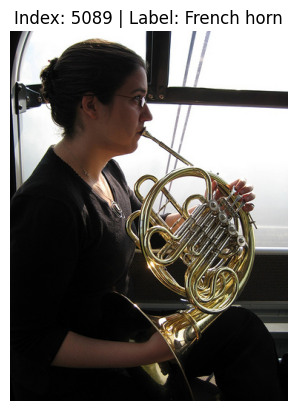

In [13]:
# 이미지 확인하기
import matplotlib.pyplot as plt
import random

test_dataset = datasets.Imagenette(root='./data_imagenette', split='train', size='full', download=True)
random_idx = random.randint(0, len(test_dataset)-1)
image, label = test_dataset[random_idx]
print(f"{random_idx} 번째 이미지 크기 (가로,세로) : {image.size}")
plt.imshow(image)
plt.title(f"Index: {random_idx} | Label: {test_dataset.classes[label][0]}")
plt.axis('off')
plt.show()

In [ ]:

num_classes = 10
model = resnet50(n_class=num_classes)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

epochs = 30
best_val_loss = float('inf')
precision_metric = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average="macro").to(device)
recall_metric    = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average="macro").to(device)
f1_metric        = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average="macro").to(device)

train_history = {"loss": [], "acc": []}
val_history = {"loss": [], "acc": []}
for epoch in range(epochs):
    
    # Training ...
    train_pbar = tqdm(train_loader, desc=f"[Epoch {epoch + 1}] Train: ", leave=False)
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0) # 배치 단위 평균 * 배치 수
        _, predicted = outputs.max(1) # 값, 인덱스 반환
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        train_pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{(correct/total)*100:.2f}%")
    train_loss = running_loss / total
    train_acc = (correct / total) * 100
        
    # Validating ...
    val_pbar = tqdm(val_loader, desc=f"[Epoch {epoch + 1}] Val:  ", leave=False)
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

            precision_metric.update(predicted, labels)
            recall_metric.update(predicted, labels)
            f1_metric.update(predicted, labels)
            
            val_pbar.set_postfix(val_loss=f"{loss.item():.4f}")
    valid_loss = val_loss / val_total
    valid_acc = (val_correct / val_total) * 100

    val_precision = precision_metric.compute().item()
    val_recall = recall_metric.compute().item()
    val_f1 = f1_metric.compute().item()
    precision_metric.reset()
    recall_metric.reset()
    f1_metric.reset()
    
    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        torch.save(model.state_dict(), 'best_resnet.pth')

    train_history['loss'].append(train_loss)
    train_history['acc'].append(train_acc)
    val_history['loss'].append(valid_loss)
    val_history['acc'].append(valid_acc)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"  [Train] Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"  [Valid] Loss: {valid_loss:.4f} | Acc: {valid_acc:.2f}%")
    print(f"  [Metrics] Precision: {val_precision:.4f} | Recall: {val_recall:.4f} | F1: {val_f1:.4f}")
    print("-" * 40)

Epoch [1/30]
  [Train] Loss: 1.7345 | Acc: 40.85%
  [Valid] Loss: 1.6684 | Acc: 42.01%
  [Metrics] Precision: 0.4755 | Recall: 0.4227 | F1: 0.3863
----------------------------------------


KeyboardInterrupt: 

In [ ]:
plt.plot(train_history['loss'])
plt.plot(val_history['loss'])
plt.title('Loss History')
plt.legend(['TRAIN', 'VAL'])
plt.plot()

In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

In [15]:
from google.colab import runtime
runtime.unassign()